<a href="https://colab.research.google.com/github/TamaraCucumides/MDS3020/blob/main/Clase2_Datos_Sinteticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clase 2 — **Generación de datos sintéticos**

**Objetivo:** Comprender qué son los datos sintéticos, por qué son relevantes en la ciencia de datos moderna y cómo generarlos de forma práctica con Python.



## 0) Preparación del entorno (Colab/Jupyter)
Ejecuta esta celda para instalar y cargar librerías. *En Colab puede tardar unos minutos.*


In [ ]:
!pip install -q faker pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, date
from math import floor
import matplotlib.pyplot as plt

print("Librerías cargadas. Versión pandas:", pd.__version__)


Librerías cargadas. Versión pandas: 2.2.2



## 1) Motivación — ¿Por qué datos sintéticos?
- **Escasez de datos**: datasets pequeños, fenómenos raros (fraude, fallas).
- **Privacidad**: no podemos compartir datos sensibles (salud, finanzas).
- **Costo/tiempo**: obtener datos reales puede ser caro o lento.
- **Docencia & pruebas**: necesitamos *datos realistas* para practicar pipelines.

**Idea clave:** Los datos sintéticos **no reemplazan** a los reales; **los complementan** y permiten experimentar con libertad y responsabilidad.



## 2) Conceptos clave
- **Definición:** datos generados artificialmente que imitan propiedades de los reales.
- **Dos enfoques comunes:**
  - *Simulación/reglas* (p. ej., [`Faker`](https://faker.readthedocs.io)): crear campos plausibles según formatos/heurísticas.
  - *Modelos generativos* (p. ej., `ydata-synthetic`, `SDV`): aprenden la **distribución** de un dataset real y generan muestras nuevas.
- **Usos típicos:** ampliar muestras, balancear clases, proteger privacidad, probar dashboards/pipelines.
- **Cuándo no usarlos:** cuando requieres exactitud clínica/forense o ya dispones de datos completos y autorizados.



## 3) Demo A — Generación con `Faker` (rápido y flexible)
**Objetivo:** crear un dataset ficticio de compras para practicar EDA, limpieza y visualización.


In [ ]:

from faker import Faker
fake = Faker('es_ES')

def generar_compras(n=1000, seed=42):
    Faker.seed(seed)
    rng = np.random.default_rng(seed)
    datos = []
    for _ in range(n):
        edad = rng.integers(18, 71)
        monto = float(np.round(rng.uniform(5.0, 500.0), 2))
        datos.append({
            "id_cliente": fake.uuid4(),
            "nombre": fake.name(),
            "edad": int(edad),
            "ciudad": fake.city(),
            "fecha_compra": fake.date_between(start_date='-6M', end_date='today'),
            "monto": monto,
            "categoria": rng.choice(["supermercado","tecnología","hogar","ropa","salud"], p=[0.35,0.2,0.15,0.2,0.1])
        })
    return pd.DataFrame(datos)

df = generar_compras(n=800, seed=2025)
df.head()


,id_cliente,nombre,edad,ciudad,fecha_compra,monto,categoria
0,d66887a3-a556-4782-952b-f8818ec8d8bc,Carmela Ángel Abad,41,Jaén,2026-03-30,194.09,ropa
1,19025fcd-669f-49ff-a1f8-416310d7543a,Benigno Galán Peña,70,La Rioja,2025-12-25,419.44,salud
2,111b3025-829d-4eed-8dc3-78970722756e,Rogelio Fajardo,38,Teruel,2026-01-26,162.14,salud
3,a381d5df-c823-4411-b0b7-cd55c93c3fbd,Águeda Seguí Pablo,22,Pontevedra,2026-01-05,339.56,supermercado
4,3e52de23-1f39-4f9a-b54b-1e0232b6e075,Alejandra Azahar Cerdán Pedro,18,Palencia,2026-03-10,118.96,supermercado


In [ ]:

# Vista general rápida
display(df.sample(5))
display(df.describe(include='all'))
print("\nTop ciudades:")
display(df['ciudad'].value_counts().head(10))


,id_cliente,nombre,edad,ciudad,fecha_compra,monto,categoria
620,b955a2b9-ca26-4171-b598-3f0c9efbefb9,Felicia Bonet Acedo,24,Alicante,2026-02-06,296.43,supermercado
14,ccaff0a4-50b8-4435-ab37-1a60ab2842d7,Manuela Gracia-Agustín,21,Toledo,2026-04-25,288.96,ropa
189,9944c088-c60d-4d8f-bfb2-068ed2cb119c,Gabino Luis Miguel Ribes Campillo,36,Granada,2026-01-04,329.33,ropa
60,61e825c2-9f70-4250-aa1b-767f73997b4a,Abigaíl Esparza Arana,61,Almería,2026-02-12,405.77,tecnología
754,118bc103-7cf9-4247-900b-aaafa4838773,Patricia Agustí Montero,29,Cáceres,2026-01-22,335.32,ropa


,id_cliente,nombre,edad,ciudad,fecha_compra,monto,categoria
count,800,800,800.000000,800,800,800.000000,800
unique,800,800,NaN,52,180,NaN,5
top,3ad5e23a-1873-4292-b7a0-2becb727988c,Jacinto Carro Andreu,NaN,Álava,2026-05-30,NaN,supermercado
freq,1,1,NaN,23,10,NaN,262
mean,NaN,NaN,42.976250,NaN,NaN,256.108650,NaN
std,NaN,NaN,15.334018,NaN,NaN,141.785406,NaN
min,NaN,NaN,18.000000,NaN,NaN,5.420000,NaN
25%,NaN,NaN,30.000000,NaN,NaN,136.867500,NaN
50%,NaN,NaN,42.000000,NaN,NaN,263.860000,NaN
75%,NaN,NaN,56.000000,NaN,NaN,377.710000,NaN



Top ciudades:


,count
ciudad,
Álava,23
Madrid,22
Cuenca,21
Huelva,21
Lleida,20
Toledo,20
Murcia,20
Salamanca,20
Tarragona,20


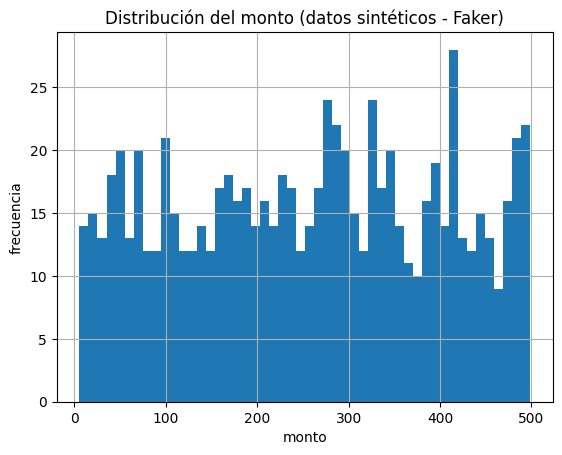

In [ ]:

# Un vistazo gráfico simple (sin estilos ni seaborn)
plt.figure()
df['monto'].hist(bins=50)
plt.title('Distribución del monto (datos sintéticos - Faker)')
plt.xlabel('monto')
plt.ylabel('frecuencia')
plt.show()



## 4) Demo B — Generación con `SDV` (opcional, más "realista")
**Idea:** aprender de un dataset real y generar uno sintético con propiedades estadísticas similares.

A continuación usamos el dataset **Iris** como ejemplo por su simplicidad.


In [ ]:
!pip install -q "sdv>=1.9,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


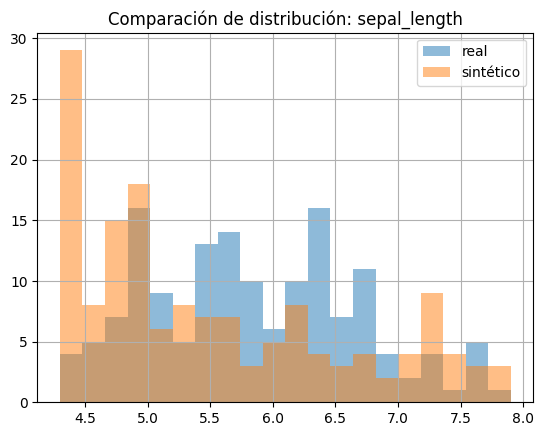

In [ ]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
import matplotlib.pyplot as plt

# 1) Cargar dataset real
df_real = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")



# 2) Detectar metadatos
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)


# 3) Entrenar sintetizador (CTGAN)
synth = CTGANSynthesizer(metadata)
synth.fit(df_real)

# 4) Generar datos sintéticos
df_synth = synth.sample(num_rows=len(df_real))

# 5) Comparar distribuciones simples
plt.figure()
df_real['sepal_length'].hist(alpha=0.5, bins=20, label='real')
df_synth['sepal_length'].hist(alpha=0.5, bins=20, label='sintético')
plt.title('Comparación de distribución: sepal_length')
plt.legend()
plt.show()


## 5) Comparación básica de distribuciones
Podemos contrastar estadísticas simples (media, desvío, cuartiles) y una métrica como **KS test** para una variable.

El KS statistic (o Kolmogorov–Smirnov test) es una prueba estadística no paramétrica usada para comparar dos distribuciones y ver si podrían provenir de la misma población.


In [ ]:
from scipy.stats import ks_2samp
real = df_real['sepal_length'].dropna().values
synth_vals = df_synth['sepal_length'].dropna().values
stat, pvalue = ks_2samp(real, synth_vals)
print(f"KS statistic: {stat:.4f} | p-value: {pvalue:.4f}")



KS statistic: 0.2667 | p-value: 0.0000


## KS statistic
Representa la distancia máxima entre las dos distribuciones acumuladas (real vs. sintética).

Un valor de 0.12 es relativamente bajo, lo que indica que las curvas se parecen bastante.

A modo de referencia:

D < 0.1 → casi idénticas.

0.1 ≤ D < 0.2 → diferencias leves.

D > 0.3 → distribuciones claramente distintas.

## p-value = 0.1804

Es mayor que el umbral común de 0.05 → no hay evidencia estadísticamente significativa de que las dos distribuciones sean diferentes.

En términos simples: no puedes rechazar la hipótesis nula de que provienen de la misma distribución.